In [1]:
import tskit
import msprime
import pyslim 
import demesdraw as dem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simple case, two trees one recombination 4 sequences

## Simulation

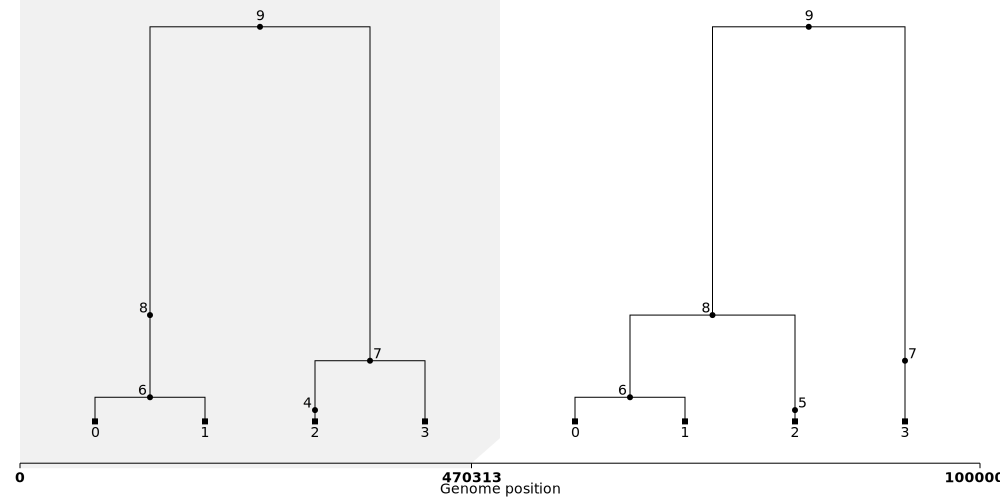

In [63]:
ts = msprime.sim_ancestry(
    2, recombination_rate=1e-7, sequence_length=1e6, random_seed=4536, record_full_arg=True)
ts.draw_svg(size=(1000,500))

In [3]:
def count_coalescents_to_common_ancestor(ts, idx_left, idx_right, node):
    tree_left = ts.at_index(idx_left)
    tree_right =ts.at_index(idx_right)

    # ancestery path for node in left tree
    anc_path_left = []
    curr = node
    while curr != tskit.NULL:
        anc_path_left.append(curr)
        curr = tree_left.parent(curr)

    # ancestery path for node in right tree
    anc_path_right = []
    curr = node
    while curr != tskit.NULL:
        anc_path_right.append(curr)
        curr = tree_right.parent(curr)

    print(anc_path_left)
    print(anc_path_right)
    mrca = [x for x in anc_path_left if x in anc_path_right and x!=node][0]
    coal_c_left = anc_path_left.index(mrca)-1
    coal_c_right = anc_path_right.index(mrca)-1
    print(mrca)
    print('coalescents left:', coal_c_left)
    print('coalescents right:', coal_c_right)

    return (coal_c_left,coal_c_right)

In [97]:
count_coalescents_to_common_ancestor(ts,0,1,2)

[2, 4, 7, 9]
[2, 5, 8, 9]
9
coalescents left: 2
coalescents right: 2


(2, 2)

### Verify which nodes that recombined

In [98]:
# Find recombination events                     
for node_id in range(ts.num_nodes - 1):         
    node1 = ts.node(node_id)                    
    if node1.flags == msprime.NODE_IS_RE_EVENT: 
        node2 = ts.node(node_id + 1)            
        if node2.flags == msprime.NODE_IS_RE_EVENT and node1.time == node2.time:                                     
            # Found a recombination event pair  
            print(f"Recombination event at nodes {node_id} and {node_id + 1}, time: {node1.time:.4f}")                              
                                                
            # Find the child (the lineage that recombined)                                     
            edges1 = [e for e in ts.edges() if e.parent == node_id]                            
            edges2 = [e for e in ts.edges() if e.parent == node_id + 1]                        
                                                
            if edges1 and edges2:               
                child = edges1[0].child         
                breakpoint = min(e.right for e in edges1)                                                                     
                print(f"  Recombinant lineage: node {child}")                                  
                print(f"  Breakpoint position: {breakpoint:.0f}")                              
                                                
                # Get descendant samples        
                tree = ts.at(breakpoint - 1)    
                descendants = list(tree.samples(child))                       
                print(f"  Descendant samples: {descendants}") 

Recombination event at nodes 4 and 5, time: 0.0863
  Recombinant lineage: node 2
  Breakpoint position: 470313
  Descendant samples: [2]


### Add mutations

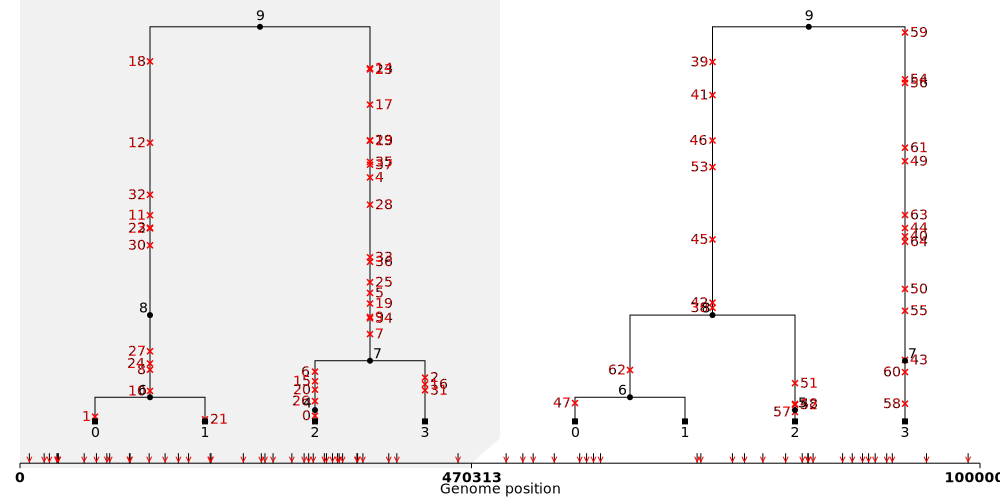

In [99]:
mts = msprime.sim_mutations(ts, rate=1e-5, random_seed=10)
mts.draw_svg(size=(1000,500))

### Anas function

In [100]:
def compute_incompatibility_matrix(ts):                                                                                                                   
    num_sites = ts.num_sites                                                      
    genotypes = ts.genotype_matrix()  # Shape: (num_sites, num_samples)           
    matrix = np.zeros((num_sites, num_sites), dtype=np.int8)                      
    for i in range(num_sites):                                                    
        for j in range(i + 1, num_sites):                                         
            g1 = genotypes[i, :]  # Genotypes at site i (0 or 1)                  
            g2 = genotypes[j, :]  # Genotypes at site j (0 or 1)                  
                                                                                
            # Encode gametes as 2-bit integers: g1 + 2*g2                         
            # 00 -> 0, 10 -> 1, 01 -> 2, 11 -> 3                                  
            gametes = g1 | (g2 << 1)                                              
                                                                                
            # Include ancestral root type (00)                                    
            gametes = np.append(gametes, 0)                                       
                                                                                
            # If all 4 gamete types exist, sites are incompatible                 
            if len(np.unique(gametes)) == 4:                                      
                matrix[i, j] = 1                                                  
                matrix[j, i] = 1  # Symmetric                                     
    return matrix                                                                 
                                                                                
# Run it                                                                          
incomp_matrix = compute_incompatibility_matrix(mts)                               
  

## Remove all noninformative sites

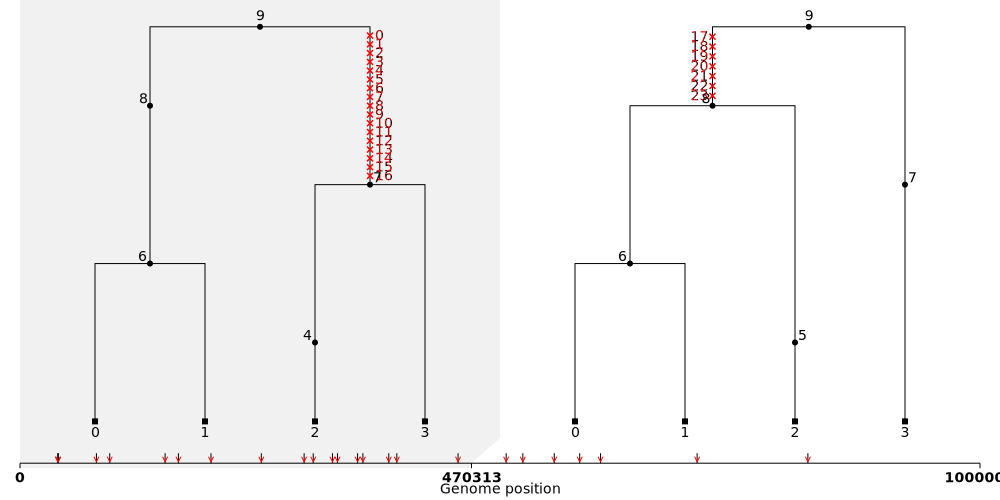

In [101]:
# Remove compatible sites                                                         
compatible_sites = np.where(~incomp_matrix.any(axis=1))[0]                        
mts_incomp = mts.delete_sites(compatible_sites)                                   
                                                                                
mts_incomp.draw_svg(size=(1000, 500), time_scale='rank') 

### Get the genotype for each of the first 10 incompatible sites for all samples

In [102]:
incompatible_sites = np.where(incomp_matrix.any(axis=1))[0]  
                                                            
# Slice the genotype matrix to keep only those sites         
genotypes = mts.genotype_matrix()                            
incomp_genotypes = genotypes[incompatible_sites, :].T           
                                                            
                              
incomp_genotypes[:, 1:10]


array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int32)

In [103]:
sites = [3,4, 48, 54]                      
genotypes[sites, :].T 

array([[1, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 1, 0],
       [0, 1, 0, 1]], dtype=int32)

### Find the incompatible pairs 

In [104]:
# Which sites is incompatible_sites[20] incompatible with?                              
site_idx = incompatible_sites[20]               
partners = np.where(incomp_matrix[site_idx, :]== 1)[0]                                        
print(f"Site {site_idx} is incompatible with sites: {partners}")                             
                                                
# Verify with the 4-gamete test                 
partner = partners[0]                           
g1 = genotypes[site_idx, :]                     
g2 = genotypes[partner, :]                      
gametes = g1 | (g2 << 1)                        
print(f"\nSite {site_idx}: {g1}")               
print(f"Site {partner}: {g2}")                  
print(f"Gametes: {np.unique(gametes)}")  # Should be [0, 1, 2, 3]                          
                                                            

Site 42 is incompatible with sites: [ 4  5  7  9 13 14 17 19 23 25 28 29 33 34 35 36 37]

Site 42: [1 1 1 0]
Site 4: [0 0 1 1]
Gametes: [1 2 3]


## Try to recode the matrix so the proportion can be calculated faster

In [105]:
pairs_i, pairs_j = np.where(np.triu(incomp_matrix) == 1)  # Upper triangle to avoid duplicates                    
num_pairs = len(pairs_i)                        
num_samples = mts.num_samples                   
                                                
print(f"Total incompatible pairs: {num_pairs}") 
                                                
# For each pair, compute gamete for each sample 
# Result: (num_pairs, num_samples) matrix with values 0,1,2,3                                  
gamete_matrix = np.zeros((num_pairs,            
num_samples), dtype=np.int8)                    
                                                
for idx, (i, j) in enumerate(zip(pairs_i,       
pairs_j)):                                      
    g1 = genotypes[i, :]                        
    g2 = genotypes[j, :]                        
    gamete_matrix[idx, :] = g1 | (g2 << 1) 

Total incompatible pairs: 119


In [106]:
# Count gamete frequencies per sample           
# Result: (num_samples, 4) - counts of each gamete type per sample                          
gamete_counts = np.zeros((num_samples, 4),      
dtype=int)                                      
for g in range(4):                              
    gamete_counts[:, g] = (gamete_matrix == g).sum(axis=0)     

In [107]:
gamete_props = gamete_counts / num_pairs  

In [108]:
df = pd.DataFrame(                              
    gamete_props,                               
    index=[f"sample_{i}" for i in range(num_samples)],                            
    columns=["00", "10", "01", "11"]            
)                                               
df   

,00,10,01,11
sample_0,0.0,0.0,1.0,0.0
sample_1,0.0,0.0,1.0,0.0
sample_2,0.0,0.0,0.0,1.0
sample_3,0.0,1.0,0.0,0.0


# Simple case, two trees, one recombination 10 sequences

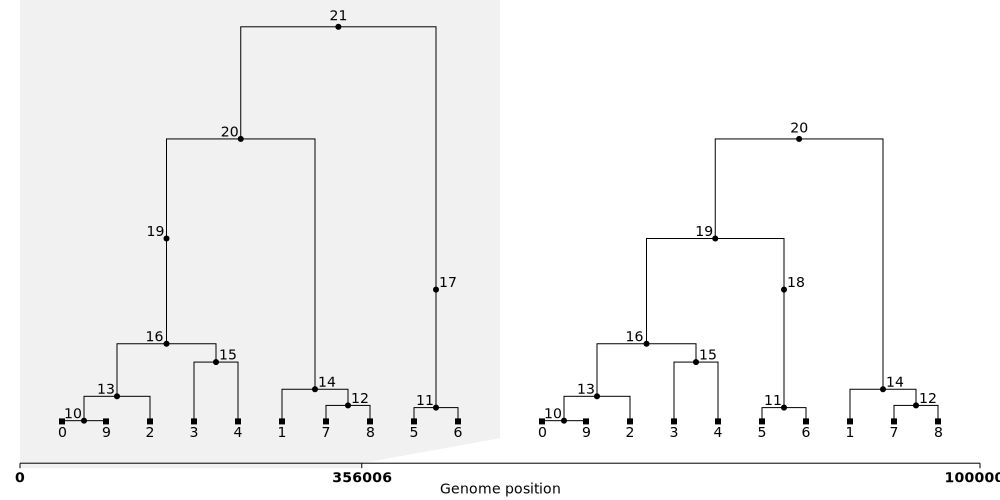

In [109]:
ts = msprime.sim_ancestry(
    5, recombination_rate=1e-7, sequence_length=1e6, random_seed=2, record_full_arg=True)
ts.draw_svg(size=(1000,500))

In [110]:
# Find recombination events                     
for node_id in range(ts.num_nodes - 1):         
    node1 = ts.node(node_id)                    
    if node1.flags == msprime.NODE_IS_RE_EVENT: 
        node2 = ts.node(node_id + 1)            
        if node2.flags == msprime.NODE_IS_RE_EVENT and node1.time == node2.time:                                     
            # Found a recombination event pair  
            print(f"Recombination event at nodes {node_id} and {node_id + 1}, time: {node1.time:.4f}")                              
                                                
            # Find the child (the lineage that recombined)                                     
            edges1 = [e for e in ts.edges() if e.parent == node_id]                            
            edges2 = [e for e in ts.edges() if e.parent == node_id + 1]                        
                                                
            if edges1 and edges2:               
                child = edges1[0].child         
                breakpoint = min(e.right for e in edges1)                                                                     
                print(f"  Recombinant lineage: node {child}")                                  
                print(f"  Breakpoint position: {breakpoint:.0f}")                              
                                                
                # Get descendant samples        
                tree = ts.at(breakpoint - 1)    
                descendants = list(tree.samples(child))                       
                print(f"  Descendant samples: {descendants}") 

Recombination event at nodes 17 and 18, time: 1.6542
  Recombinant lineage: node 11
  Breakpoint position: 356006
  Descendant samples: [5, 6]


### Add mutations

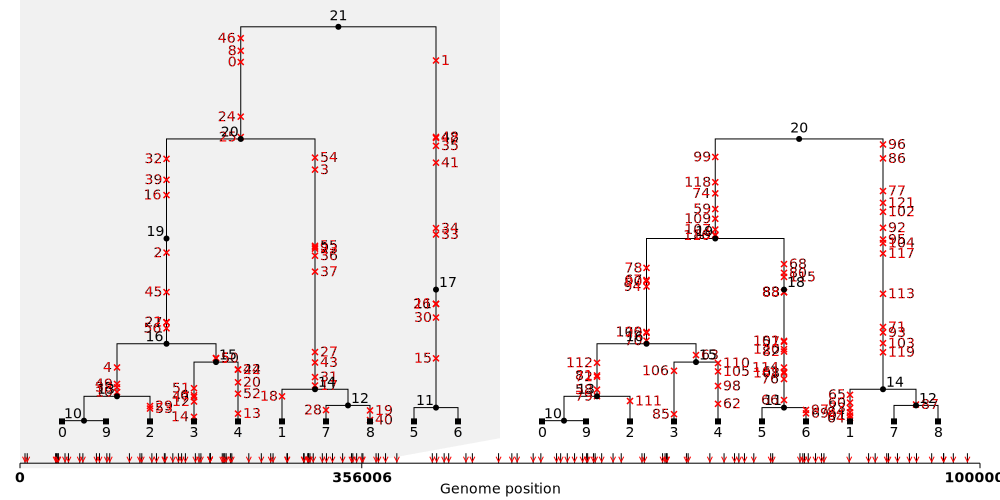

In [111]:
mts = msprime.sim_mutations(ts, rate=1e-5, random_seed=10)
mts.draw_svg(size=(1000,500))

### Run anas function

In [2]:
def compute_incompatibility_matrix(ts):                                                                                                                   
    num_sites = ts.num_sites                                                      
    genotypes = ts.genotype_matrix()  # Shape: (num_sites, num_samples)           
    matrix = np.zeros((num_sites, num_sites), dtype=np.int8)                      
    for i in range(num_sites):                                                    
        for j in range(i + 1, num_sites):                                         
            g1 = genotypes[i, :]  # Genotypes at site i (0 or 1)                  
            g2 = genotypes[j, :]  # Genotypes at site j (0 or 1)                  
                                                                                
            # Encode gametes as 2-bit integers: g1 + 2*g2                         
            # 00 -> 0, 10 -> 1, 01 -> 2, 11 -> 3                                  
            gametes = g1 | (g2 << 1)                                              
                                                                                
            # Include ancestral root type (00)                                    
            gametes = np.append(gametes, 0)                                       
                                                                                
            # If all 4 gamete types exist, sites are incompatible                 
            if len(np.unique(gametes)) == 4:                                      
                matrix[i, j] = 1                                                  
                matrix[j, i] = 1  # Symmetric                                     
    return matrix                                                                 
                                                                                
# Run it                                                                          
incomp_matrix = compute_incompatibility_matrix(mts)                               
  

NameError: name 'mts' is not defined

### Remove all non-informative sites

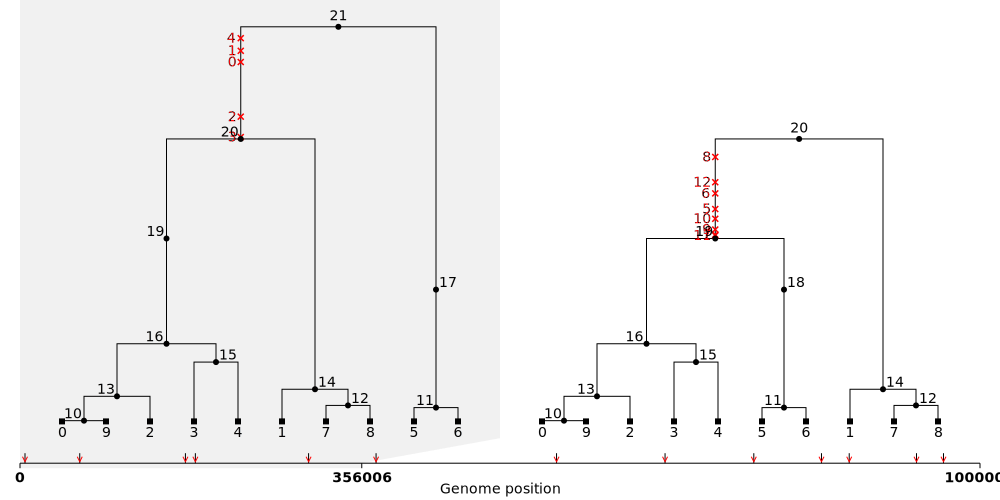

In [113]:
# Remove compatible sites                                                         
compatible_sites = np.where(~incomp_matrix.any(axis=1))[0]                        
mts_incomp = mts.delete_sites(compatible_sites)                                   
                                                                                
mts_incomp.draw_svg(size=(1000, 500)) 

### Recode matrix, to calculate proportion fast 

In [114]:
pairs_i, pairs_j = np.where(np.triu(incomp_matrix) == 1)  # Upper triangle to avoid duplicates                    
num_pairs = len(pairs_i)                        
num_samples = mts.num_samples    
genotypes = mts.genotype_matrix()                  
                                                
print(f"Total incompatible pairs: {num_pairs}") 
                                                
# For each pair, compute gamete for each sample 
# Result: (num_pairs, num_samples) matrix with values 0,1,2,3                                  
gamete_matrix = np.zeros((num_pairs,            
num_samples), dtype=np.int8)                    
                                                
for idx, (i, j) in enumerate(zip(pairs_i,       
pairs_j)):                                      
    g1 = genotypes[i, :]                        
    g2 = genotypes[j, :]                        
    gamete_matrix[idx, :] = g1 | (g2 << 1) 

Total incompatible pairs: 40


In [116]:
# Count gamete frequencies per sample           
# Result: (num_samples, 4) - counts of each gamete type per sample                          
gamete_counts = np.zeros((num_samples, 4),      
dtype=int)                                      
for g in range(4):                              
    gamete_counts[:, g] = (gamete_matrix == g).sum(axis=0)     

In [117]:
gamete_props = gamete_counts / num_pairs  

In [118]:
df = pd.DataFrame(                              
    gamete_props,                               
    index=[f"sample_{i}" for i in range(num_samples)],                            
    columns=["00", "10", "01", "11"]            
)                                               
df   

,00,10,01,11
sample_0,0.0,0.0,0.0,1.0
sample_1,0.0,1.0,0.0,0.0
sample_2,0.0,0.0,0.0,1.0
sample_3,0.0,0.0,0.0,1.0
sample_4,0.0,0.0,0.0,1.0
sample_5,0.0,0.0,1.0,0.0
sample_6,0.0,0.0,1.0,0.0
sample_7,0.0,1.0,0.0,0.0
sample_8,0.0,1.0,0.0,0.0
sample_9,0.0,0.0,0.0,1.0


# How often are we correct (simple Case 2 trees)

[203773.44413827]


/tmp/ipykernel_3346380/3540882006.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  10, recombination_rate=1e-7, sequence_length=1e6, random_seed=int(seed), record_full_arg=True)


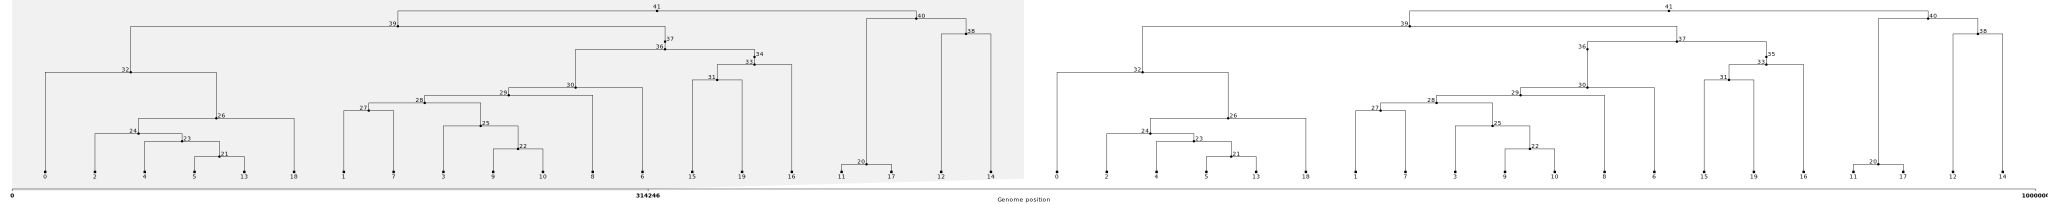

In [91]:
for i in range(1,1000):
    seed = np.random.uniform(1,1000000,1)
    print(seed)
    ts = msprime.sim_ancestry(
        10, recombination_rate=1e-7, sequence_length=1e6, random_seed=int(seed), record_full_arg=True)
    if ts.num_trees == 2:
        break
ts.draw_svg(size=(5000,500), time_scale='rank')

In [92]:
# mts_1 = mts.simplify([s for s in mts.samples() if s not in [0,11]])
# mts_2 = mts_1.simplify([s for s in mts_1.samples() if s not in [2,5]])


In [93]:
child = None
descendants = None
for node_id in range(ts.num_nodes - 1):
    node1 = ts.node(node_id)
    if node1.flags == msprime.NODE_IS_RE_EVENT:
        node2 = ts.node(node_id + 1)
        if node2.flags == msprime.NODE_IS_RE_EVENT and node1.time == node2.time:
            edges1 = [e for e in ts.edges() if e.parent == node_id]
            edges2 = [e for e in ts.edges() if e.parent == node_id + 1]
            if edges1 and edges2:
                child = edges1[0].child
                breakpoint_pos = min(e.right for e in edges1)
                tree = ts.at(breakpoint_pos - 1)
                print(child)
                descendants = list(tree.samples(child))

descendants

33


[16, 15, 19]

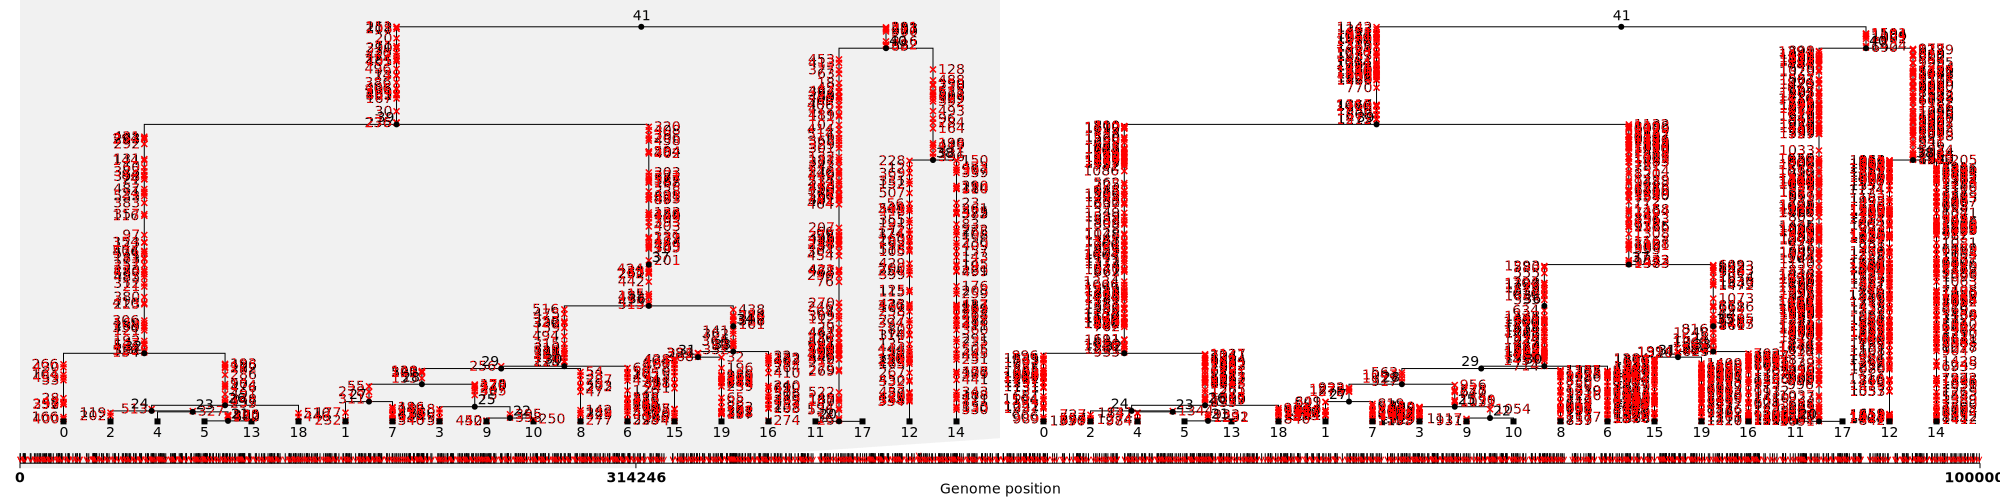

In [94]:
mts = msprime.sim_mutations(ts, rate=1e-4, random_seed=10)
mts.draw_svg(size=(2000,500))

In [95]:
mts.num_mutations


1546

In [96]:
mts.num_sites

1545

In [98]:
def find_recsites(ts):
    recsites = set()
    for s in ts.sites():
        if len(s.mutations) > 1:
            recsites.add(s.id)
    return recsites




def compute_incompatibility_matrix(ts,recsites=set()):      
                                                                                                                 
    num_sites = ts.num_sites            
    genotypes = ts.genotype_matrix()  # Shape: (num_sites, num_samples)           
    matrix = np.zeros((num_sites, num_sites), dtype=np.int8)                      
    for i in range(num_sites):   
        if i not in recsites:                                                 
            for j in range(i + 1, num_sites):
                if j not in recsites:                                         
                    g1 = genotypes[i, :]  # Genotypes at site i (0 or 1)                  
                    g2 = genotypes[j, :]  # Genotypes at site j (0 or 1)                  
                                                                                        
                    # Encode gametes as 2-bit integers: g1 + 2*g2                         
                    # 00 -> 0, 10 -> 1, 01 -> 2, 11 -> 3                                  
                    gametes = g1 | (g2 << 1)                                              
                                                                                        
                    # Include ancestral root type (00)                                    
                    gametes = np.append(gametes, 0)                                       
                                                                                        
                    # If all 4 gamete types exist, sites are incompatible                 
                    if len(np.unique(gametes)) == 4:                                      
                        matrix[i, j] = 1                                                  
                        matrix[j, i] = 1  # Symmetric                                     
    return matrix                                                                 
                                                                                
# Run it                                                                          
incomp_matrix = compute_incompatibility_matrix(mts, recsites=find_recsites(mts))                               
  

In [ ]:
# # Remove compatible sites                                                         
# compatible_sites = np.where(~incomp_matrix.any(axis=1))[0]                        
# # mts_incomp = mts_1.delete_sites(compatible_sites)                                   
                                                                                
# # mts_incomp.draw_svg(size=(2000, 500), time_scale='rank') 

In [83]:
# count_coalescents_to_common_ancestor(mts,0,1,45)

In [99]:
pairs_i, pairs_j = np.where(np.triu(incomp_matrix) == 1)  # Upper triangle to avoid duplicates                    
num_pairs = len(pairs_i)                        
num_samples = mts.num_samples    
genotypes = mts.genotype_matrix()                  
                                                
print(f"Total incompatible pairs: {num_pairs}") 
                                                
# For each pair, compute gamete for each sample 
# Result: (num_pairs, num_samples) matrix with values 0,1,2,3                                  
gamete_matrix = np.zeros((num_pairs,            
num_samples), dtype=np.int8)                    
                                                
for idx, (i, j) in enumerate(zip(pairs_i,       
pairs_j)):                                      
    g1 = genotypes[i, :]                        
    g2 = genotypes[j, :]                        
    gamete_matrix[idx, :] = g1 | (g2 << 1) 

# Count gamete frequencies per sample           
# Result: (num_samples, 4) - counts of each gamete type per sample                          
gamete_counts = np.zeros((num_samples, 4),      
dtype=int)                                      
for g in range(4):                              
    gamete_counts[:, g] = (gamete_matrix == g).sum(axis=0)     

gamete_props = gamete_counts / num_pairs  

df = pd.DataFrame(                              
    gamete_props,                               
    index=[f"sample_{i}" for i in range(num_samples)],                            
    columns=["00", "10", "01", "11"]            
)                                               
df   

Total incompatible pairs: 0


/tmp/ipykernel_3346380/3089744885.py:26: RuntimeWarning: invalid value encountered in divide
  gamete_props = gamete_counts / num_pairs


,00,10,01,11
sample_0,NaN,NaN,NaN,NaN
sample_1,NaN,NaN,NaN,NaN
sample_2,NaN,NaN,NaN,NaN
sample_3,NaN,NaN,NaN,NaN
sample_4,NaN,NaN,NaN,NaN
sample_5,NaN,NaN,NaN,NaN
sample_6,NaN,NaN,NaN,NaN
sample_7,NaN,NaN,NaN,NaN
sample_8,NaN,NaN,NaN,NaN
sample_9,NaN,NaN,NaN,NaN


In [100]:
df['11'].max()
df.loc[df['11']==df['11'].max()]

,00,10,01,11


In [101]:
child = None
descendants = None
for node_id in range(ts.num_nodes - 1):
    node1 = ts.node(node_id)
    if node1.flags == msprime.NODE_IS_RE_EVENT:
        node2 = ts.node(node_id + 1)
        if node2.flags == msprime.NODE_IS_RE_EVENT and node1.time == node2.time:
            edges1 = [e for e in ts.edges() if e.parent == node_id]
            edges2 = [e for e in ts.edges() if e.parent == node_id + 1]
            if edges1 and edges2:
                child = edges1[0].child
                breakpoint_pos = min(e.right for e in edges1)
                tree = ts.at(breakpoint_pos - 1)
                descendants = list(tree.samples(child))

descendants

[16, 15, 19]

# Multiple trees 

[77978.66489886]
[338204.15631362]
[228194.92777501]
[311007.16756913]
[171806.71256246]
[461308.10729608]
[618216.073116]
[682548.96229061]
[238279.10499178]
[587000.00207859]
[281458.93571497]
[484491.30969307]
[935711.63705167]


/tmp/ipykernel_390688/4248738235.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  10, recombination_rate=1e-7, sequence_length=1e6, random_seed=int(seed), record_full_arg=True)


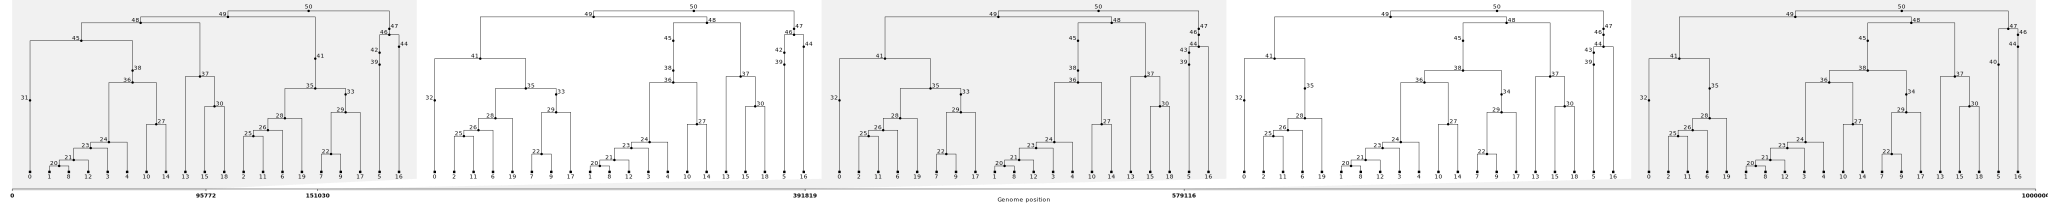

In [5]:
for i in range(1,1000):
    seed = np.random.uniform(1,1000000,1)
    print(seed)
    ts = msprime.sim_ancestry(
        10, recombination_rate=1e-7, sequence_length=1e6, random_seed=int(seed), record_full_arg=True)
    if ts.num_trees == 5:
        break
ts.draw_svg(size=(5000,500), time_scale='rank')

In [ ]:
# function to add mutations to all branches and all substrees

def add_mutations(ts):
    tables = ts.tables
    new_mutation_table = tables.mutations
    new_mutation_table.clear()
    new_site_table = tables.sites
    new_site_table.clear()
    s = 0
    t_n = np.zeros(ts.num_trees)
    for e in ts.edges():
            t = ts.at(e.left)
            if not t.is_sample(e.child):
                while t.interval[0] < e.right and t.index != -1:
                    new_site_table.add_row(
                        position=t.interval[0]
                        + (t_n[t.index] + 1)
                        * (t.interval[1] - t.interval[0])
                        / (t.num_nodes - t.num_samples() - 1),
                        ancestral_state="A",
                    )
                    t_n[t.index] += 1
                    new_mutation_table.add_row(
                        site=s, node=e.child, derived_state="G", time=None
                    )
                    s += 1
                    t.next()

    tables.sort()
    ts_ = tables.tree_sequence()
    return ts_

def find_recsites(ts):
    recsites = set()
    for s in ts.sites():
        if len(s.mutations) > 1:
            recsites.add(s.id)
    return recsites


def compute_incompatibility_matrix(ts,recsites=set()):      
                                                                                                                 
    num_sites = ts.num_sites            
    genotypes = ts.genotype_matrix()  # Shape: (num_sites, num_samples)           
    matrix = np.zeros((num_sites, num_sites), dtype=np.int8)                      
    for i in range(num_sites):   
        if i not in recsites:                                                 
            for j in range(i + 1, num_sites):
                if j not in recsites:                                         
                    g1 = genotypes[i, :]  # Genotypes at site i (0 or 1)                  
                    g2 = genotypes[j, :]  # Genotypes at site j (0 or 1)                  
                                                                                        
                    # Encode gametes as 2-bit integers: g1 + 2*g2                         
                    # 00 -> 0, 10 -> 1, 01 -> 2, 11 -> 3                                  
                    gametes = g1 | (g2 << 1)                                              
                                                                                        
                    # Include ancestral root type (00)                                    
                    gametes = np.append(gametes, 0)                                       
                                                                                        
                    # If all 4 gamete types exist, sites are incompatible                 
                    if len(np.unique(gametes)) == 4:                                      
                        matrix[i, j] = 1                                                  
                        matrix[j, i] = 1  # Symmetric                                     
    return matrix                                                                 
                                                                                
                             
  

/home/bjarkemp/miniforge3/envs/recapitation/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3699: FutureWarning: This property is a deprecated alias for Tree.tree_sequence.num_nodes and will be removed in the future. To obtain the number of nodes in the topology of the current tree (i.e. reachable from the roots) use len(tree.preorder()).
  exec(code_obj, self.user_global_ns, self.user_ns)


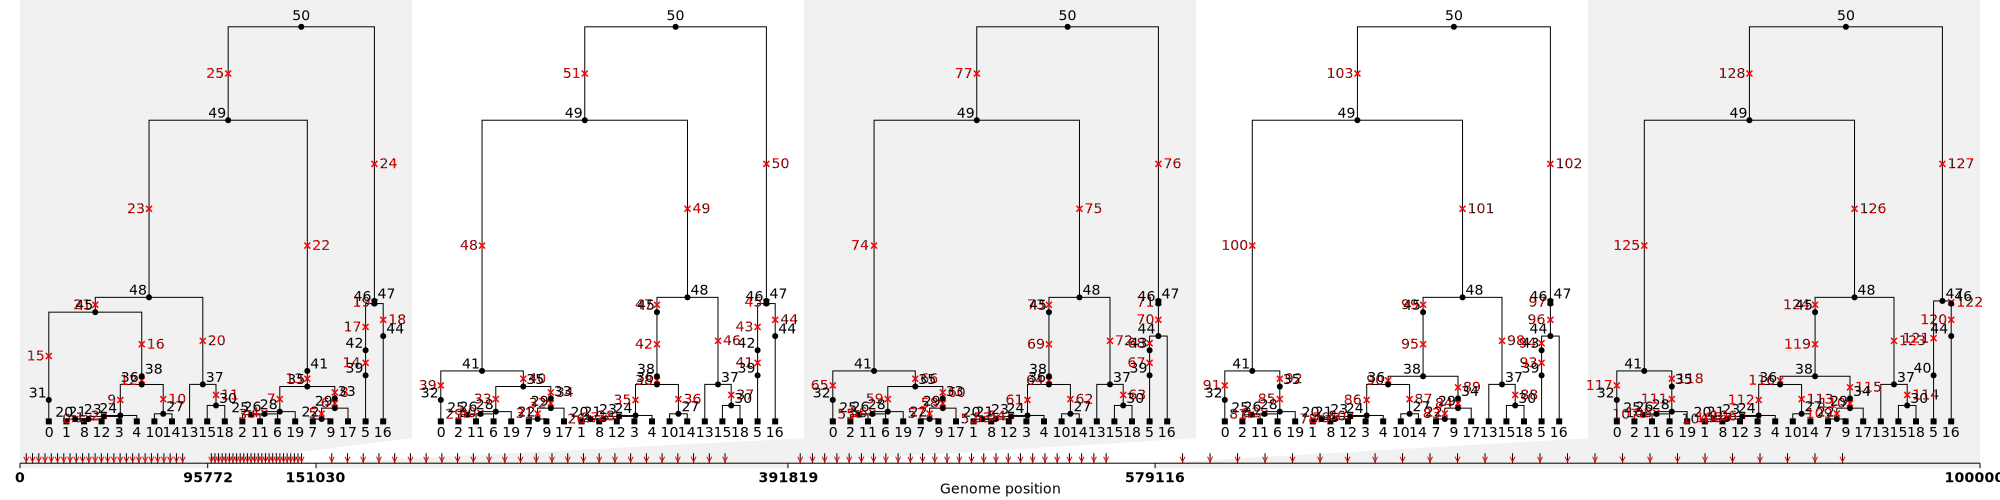

In [8]:
mts = add_mutations(ts)
mts.draw_svg(size=(2000,500))

In [ ]:
# Run it                                                                          
incomp_matrix = compute_incompatibility_matrix(mts, recsites=find_recsites(mts))  

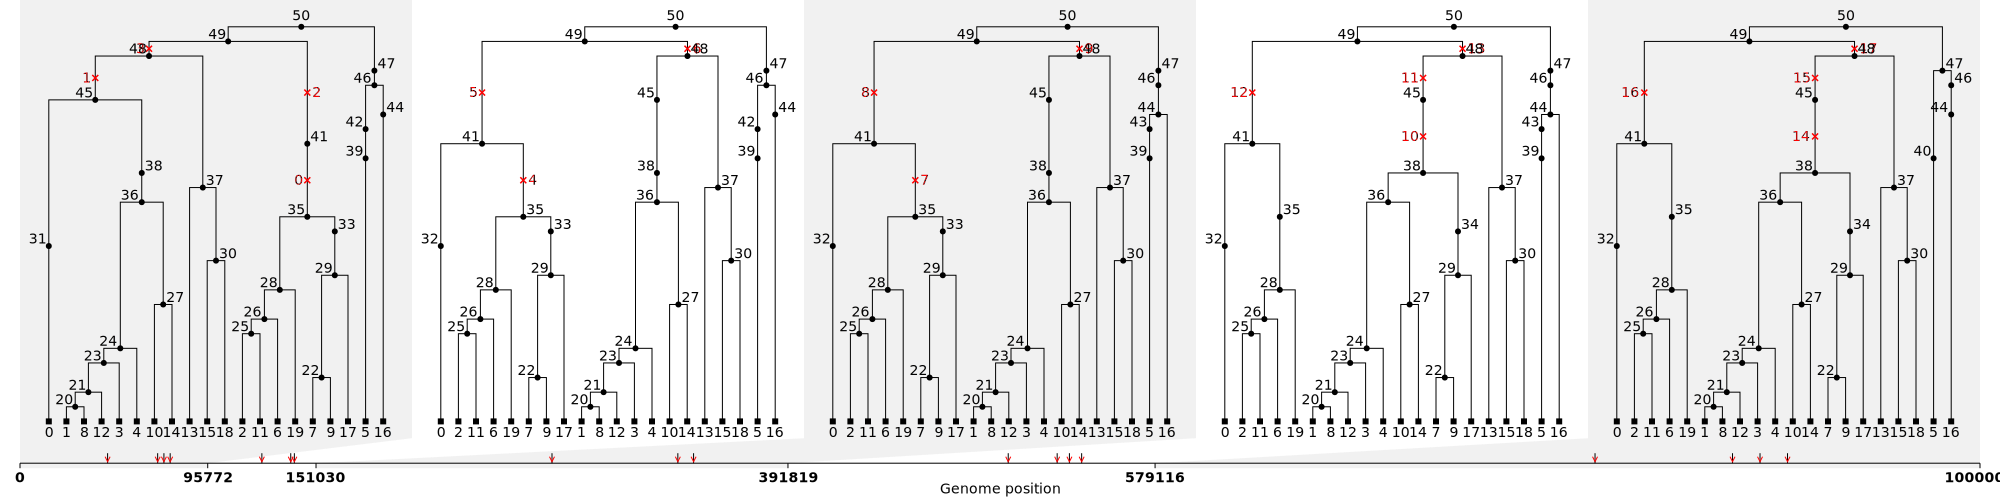

In [11]:
compatible_sites = np.where(~incomp_matrix.any(axis=1))[0]                        
mts_incomp = mts.delete_sites(compatible_sites)                                   
                                                                                
mts_incomp.draw_svg(size=(2000, 500), time_scale='rank') 

In [12]:
pairs_i, pairs_j = np.where(np.triu(incomp_matrix) == 1)  # Upper triangle to avoid duplicates                    
num_pairs = len(pairs_i)                        
num_samples = mts.num_samples    
genotypes = mts.genotype_matrix()                  
                                                
print(f"Total incompatible pairs: {num_pairs}") 
                                                
# For each pair, compute gamete for each sample 
# Result: (num_pairs, num_samples) matrix with values 0,1,2,3                                  
gamete_matrix = np.zeros((num_pairs,            
num_samples), dtype=np.int8)                    
                                                
for idx, (i, j) in enumerate(zip(pairs_i,       
pairs_j)):                                      
    g1 = genotypes[i, :]                        
    g2 = genotypes[j, :]                        
    gamete_matrix[idx, :] = g1 | (g2 << 1) 

# Count gamete frequencies per sample           
# Result: (num_samples, 4) - counts of each gamete type per sample                          
gamete_counts = np.zeros((num_samples, 4),      
dtype=int)                                      
for g in range(4):                              
    gamete_counts[:, g] = (gamete_matrix == g).sum(axis=0)     

gamete_props = gamete_counts / num_pairs  

df = pd.DataFrame(                              
    gamete_props,                               
    index=[f"sample_{i}" for i in range(num_samples)],                            
    columns=["00", "10", "01", "11"]            
)                                               
df   

Total incompatible pairs: 74


,00,10,01,11
sample_0,0.432432,0.351351,0.108108,0.108108
sample_1,0.108108,0.108108,0.486486,0.297297
sample_2,0.297297,0.486486,0.108108,0.108108
sample_3,0.108108,0.108108,0.486486,0.297297
sample_4,0.108108,0.108108,0.486486,0.297297
sample_5,1.000000,0.000000,0.000000,0.000000
sample_6,0.297297,0.486486,0.108108,0.108108
sample_7,0.081081,0.108108,0.324324,0.486486
sample_8,0.108108,0.108108,0.486486,0.297297
sample_9,0.081081,0.108108,0.324324,0.486486


## From simulations (plotting)

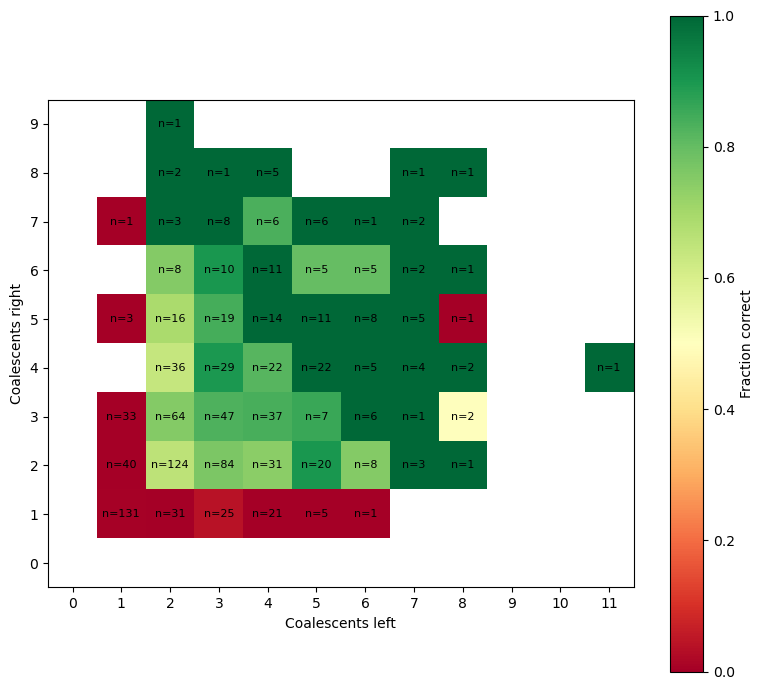

In [13]:
df = pd.read_csv('results/sim_n15.csv', index_col=0)
fig, ax = plt.subplots(figsize=(8, 7))

# Count total and correct per (coal_left, coal_right) tile                                         
grouped = df.groupby(['coal_left', 'coal_right'])
total = grouped.size()                                                                             
correct_count = grouped['correct'].sum()
frac_correct = (correct_count / total)

# Build matrices for heatmap
max_left = int(df['coal_left'].max())
max_right = int(df['coal_right'].max())
frac_matrix = np.full((max_right + 1, max_left + 1), np.nan)
total_matrix = np.zeros((max_right + 1, max_left + 1), dtype=int)

for (cl, cr), frac in frac_correct.items():
    frac_matrix[cr, cl] = frac
    total_matrix[cr, cl] = total[(cl, cr)]

im = ax.imshow(frac_matrix, origin='lower', cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
plt.colorbar(im, ax=ax, label='Fraction correct')

# Annotate each tile with the count
for cl in range(max_left + 1):
    for cr in range(max_right + 1):
        if total_matrix[cr, cl] > 0:
            ax.text(cl, cr, f'n={total_matrix[cr, cl]}', ha='center', va='center', fontsize=8)

ax.set_xlabel('Coalescents left')
ax.set_ylabel('Coalescents right')
ax.set_xticks(range(max_left + 1))
ax.set_yticks(range(max_right + 1))
plt.tight_layout()

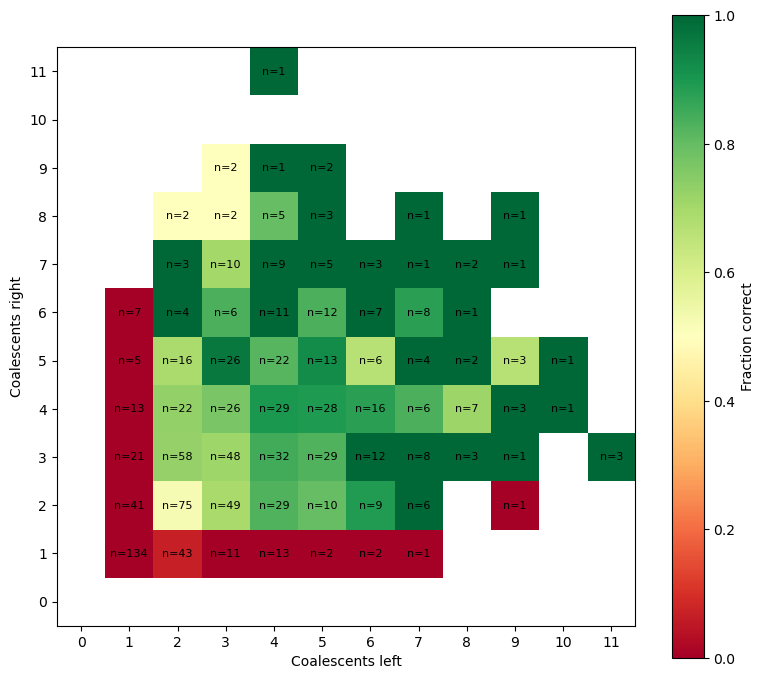

In [14]:
df = pd.read_csv('results/sim_n25.csv', index_col=0)
fig, ax = plt.subplots(figsize=(8, 7))

# Count total and correct per (coal_left, coal_right) tile                                         
grouped = df.groupby(['coal_left', 'coal_right'])
total = grouped.size()                                                                             
correct_count = grouped['correct'].sum()
frac_correct = (correct_count / total)

# Build matrices for heatmap
max_left = int(df['coal_left'].max())
max_right = int(df['coal_right'].max())
frac_matrix = np.full((max_right + 1, max_left + 1), np.nan)
total_matrix = np.zeros((max_right + 1, max_left + 1), dtype=int)

for (cl, cr), frac in frac_correct.items():
    frac_matrix[cr, cl] = frac
    total_matrix[cr, cl] = total[(cl, cr)]

im = ax.imshow(frac_matrix, origin='lower', cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
plt.colorbar(im, ax=ax, label='Fraction correct')

# Annotate each tile with the count
for cl in range(max_left + 1):
    for cr in range(max_right + 1):
        if total_matrix[cr, cl] > 0:
            ax.text(cl, cr, f'n={total_matrix[cr, cl]}', ha='center', va='center', fontsize=8)

ax.set_xlabel('Coalescents left')
ax.set_ylabel('Coalescents right')
ax.set_xticks(range(max_left + 1))
ax.set_yticks(range(max_right + 1))
plt.tight_layout()

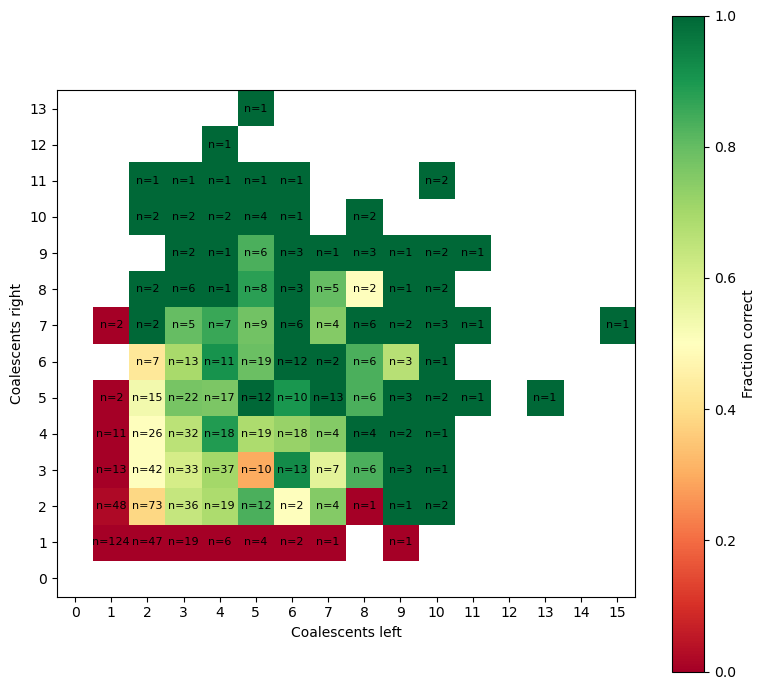

In [15]:
df = pd.read_csv('results/sim_n50.csv', index_col=0)
fig, ax = plt.subplots(figsize=(8, 7))

# Count total and correct per (coal_left, coal_right) tile                                         
grouped = df.groupby(['coal_left', 'coal_right'])
total = grouped.size()                                                                             
correct_count = grouped['correct'].sum()
frac_correct = (correct_count / total)

# Build matrices for heatmap
max_left = int(df['coal_left'].max())
max_right = int(df['coal_right'].max())
frac_matrix = np.full((max_right + 1, max_left + 1), np.nan)
total_matrix = np.zeros((max_right + 1, max_left + 1), dtype=int)

for (cl, cr), frac in frac_correct.items():
    frac_matrix[cr, cl] = frac
    total_matrix[cr, cl] = total[(cl, cr)]

im = ax.imshow(frac_matrix, origin='lower', cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
plt.colorbar(im, ax=ax, label='Fraction correct')

# Annotate each tile with the count
for cl in range(max_left + 1):
    for cr in range(max_right + 1):
        if total_matrix[cr, cl] > 0:
            ax.text(cl, cr, f'n={total_matrix[cr, cl]}', ha='center', va='center', fontsize=8)

ax.set_xlabel('Coalescents left')
ax.set_ylabel('Coalescents right')
ax.set_xticks(range(max_left + 1))
ax.set_yticks(range(max_right + 1))
plt.tight_layout()

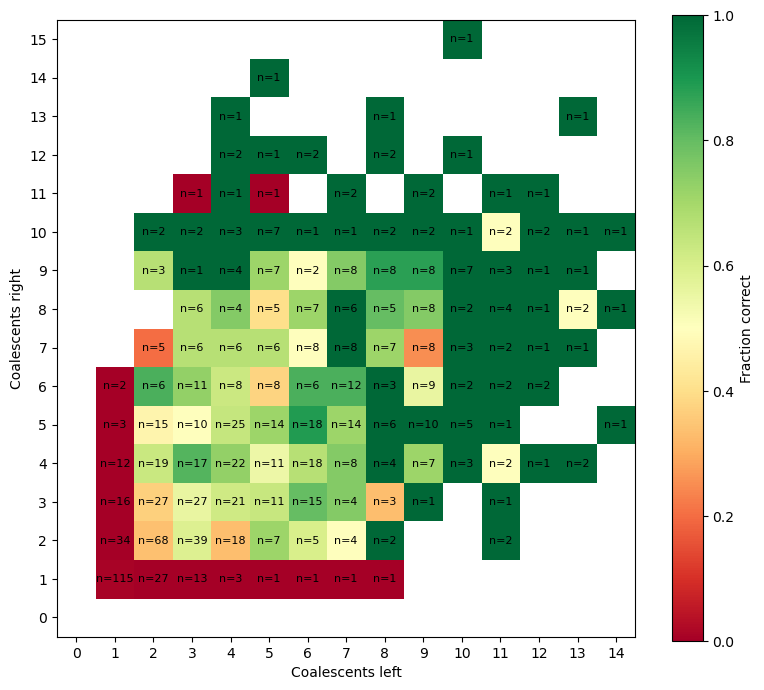

In [16]:
df = pd.read_csv('results/sim_n100.csv', index_col=0)
fig, ax = plt.subplots(figsize=(8, 7))

# Count total and correct per (coal_left, coal_right) tile                                         
grouped = df.groupby(['coal_left', 'coal_right'])
total = grouped.size()                                                                             
correct_count = grouped['correct'].sum()
frac_correct = (correct_count / total)

# Build matrices for heatmap
max_left = int(df['coal_left'].max())
max_right = int(df['coal_right'].max())
frac_matrix = np.full((max_right + 1, max_left + 1), np.nan)
total_matrix = np.zeros((max_right + 1, max_left + 1), dtype=int)

for (cl, cr), frac in frac_correct.items():
    frac_matrix[cr, cl] = frac
    total_matrix[cr, cl] = total[(cl, cr)]

im = ax.imshow(frac_matrix, origin='lower', cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
plt.colorbar(im, ax=ax, label='Fraction correct')

# Annotate each tile with the count
for cl in range(max_left + 1):
    for cr in range(max_right + 1):
        if total_matrix[cr, cl] > 0:
            ax.text(cl, cr, f'n={total_matrix[cr, cl]}', ha='center', va='center', fontsize=8)

ax.set_xlabel('Coalescents left')
ax.set_ylabel('Coalescents right')
ax.set_xticks(range(max_left + 1))
ax.set_yticks(range(max_right + 1))
plt.tight_layout()